# Bayesian Parameter Estimation


In [1]:
load("/MATLAB Drive/ECE 271A_Statistical_learning/homework3/TrainingSamplesDCT_subsets_8.mat")
load("/MATLAB Drive/ECE 271A_Statistical_learning/homework3/Alpha.mat")

load("/MATLAB Drive/ECE 271A_Statistical_learning/homework3/Prior_1.mat")
W0_1 = W0';
mu_0_FG_1 = mu0_FG';
mu_0_BG_1 = mu0_BG';

clear W0 mu0_FG mu0_BG

load("/MATLAB Drive/ECE 271A_Statistical_learning/homework3/Prior_2.mat")
W0_2 = W0';
mu_0_FG_2 = mu0_FG';
mu_0_BG_2 = mu0_BG';

mean_prior = {mu_0_FG_1,mu_0_FG_2,mu_0_BG_1,mu_0_BG_2,W0_1,W0_2};
data = {D1_FG,D2_FG,D3_FG,D4_FG,D1_BG,D2_BG,D3_BG,D4_BG};

clear W0 mu0_FG mu0_BG W0_1 mu_0_FG_1 mu_0_BG_1 W0_2 mu_0_FG_2 mu_0_BG_2 D1_FG D2_FG D3_FG D4_FG D1_BG D2_BG D3_BG D4_BG


In this work, we are comparing the performance of Bayesian Estimation, Maximum a Posterior Estimation and Maximum Likelihood Estimation for the task of image segmentation under different conditions namely :

1. Number of data points - affects class conditional mean and covariance
2. Mean of gaussian prior of class conditional mean
3. Covariance of gaussian prior of class conditional mean

**Maximum Likelihood Estimation**


In this estimation, we select the parameter $\mu_{ML}$ with maximizes the likelihood $P_{T|\mu } (D|\mu )$ . For the case of Gaussian distribution


 $P_{X|T} (x|D)=P_{X|\mu ,\Sigma } (x|\mu_{ML} ,\Sigma )=G(x,\hat{\mu} ,\Sigma )$ , $\hat{\mu}$ is the sample mean


 **Maximum A Posteriori Estimation**


In this estimation, we include another information that the parameters are obtained from some known distribution. So, in addition to data we are infusing the prior information on how parameters behave. In MAP, we assume that the variance (spread) of the posteriori distribution of mean is small and the estimation takes the value which maximizes the posterior distribution.


 $\mu_{MAP} ={\textrm{argmax}}_{\mu } P_{\mu |T} (\mu |D)=\mu_n$ \- for the case of Gaussian distribution, Then


$$P_{X|T} (x|D)=P_{X|\mu ,\Sigma } (x|\mu_{MAP} ,\Sigma )=G(x,\mu_n ,\Sigma )$$


**Bayesian Parameter Estimation**


In this estimation, we include another information that the parameters are obtained from some known distribution. So, in addition to data we are infusing the prior information on how parameters behave. In Bayesian Parameter Estimation, we don't neglect any information and use all of them.


The class conditioned distribution is obtained by finding the expectation of parameterized class conditional distribution function.


$$P_{X|T} (x|D)={\mathrm{E}}[P_{X|\mu } (x|\mu )]=\int_{\mu } P_{X|\mu } (x|\mu )*P_{\mu |T} (\mu |D)d\mu$$

The posterior $P_{\mu |T} (\mu |D)$ given that the prior is $P_{\mu } (\mu )=G(\mu ,\mu_0 ,\Sigma_0 )$ . and $P_{X|\mu ;\Sigma } =G(x,\mu ;\Sigma )$ is


$$\begin{array}{l} P_{\mu |T} (\mu |D_1 )\propto P_{\mu } (\mu )*\prod_{i=1}^N P_{X|\mu } (x_i |\mu )\newline  \end{array}$$

Since $P_{X|\mu ;\Sigma } ,P_{\mu } (\mu )$ are gaussian, their product will be gaussian of the form :


$$P_{\mu |T} (\mu |D)=G(\mu ,\mu_n ,\Sigma_n )$$

Where,


 $\Sigma_n^{-1} =(N\Sigma^{-1} +\Sigma_0^{-1} )\;\,$ and


$$\Sigma_n^{-1} \mu_n =\Sigma^{-1} \Sigma_i x_i +\Sigma_0^{-1} \mu_0 =N\Sigma^{-1} \frac{\Sigma_i x_i }{N}+\Sigma_0^{-1} \mu_0 =N\Sigma^{-1} \hat{\mu} +\Sigma_0^{-1} \mu_0 \;$$

 $\hat{\mu}$ is the sample mean, N is the number of data points. Solving we get


$$\Sigma_n =\Sigma_0 (\Sigma_0 +\frac{1}{N}\Sigma )^{-1} \frac{1}{N}\Sigma \,$$

$$\mu_n =\Sigma_0 (\Sigma_0 +\frac{1}{N}\Sigma )^{-1} \hat{\mu} +\frac{1}{N}\Sigma (\Sigma_0 +\frac{1}{N}\Sigma )^{-1} \mu_0$$

Then


$$P_{X|T} (x|D)={\mathrm{E}}[P_{X|\mu } (x|\mu )]=\int_{\mu } P_{X|\mu } (x|\mu )*P_{\mu |T} (\mu |D)d\mu =\int_{\mu } G(x,\mu ,\Sigma )*G(\mu ,\mu_n ,\Sigma_n )d\mu =G(x,\mu_n ,\Sigma_n +\Sigma )$$


The obtained class conditional distribution is then multiplied by class priors and compared as per Bayesian Decision Rule


The classifier is written as a MATLAB class **Bayesian_decision** 


Importing and preprocessing the image



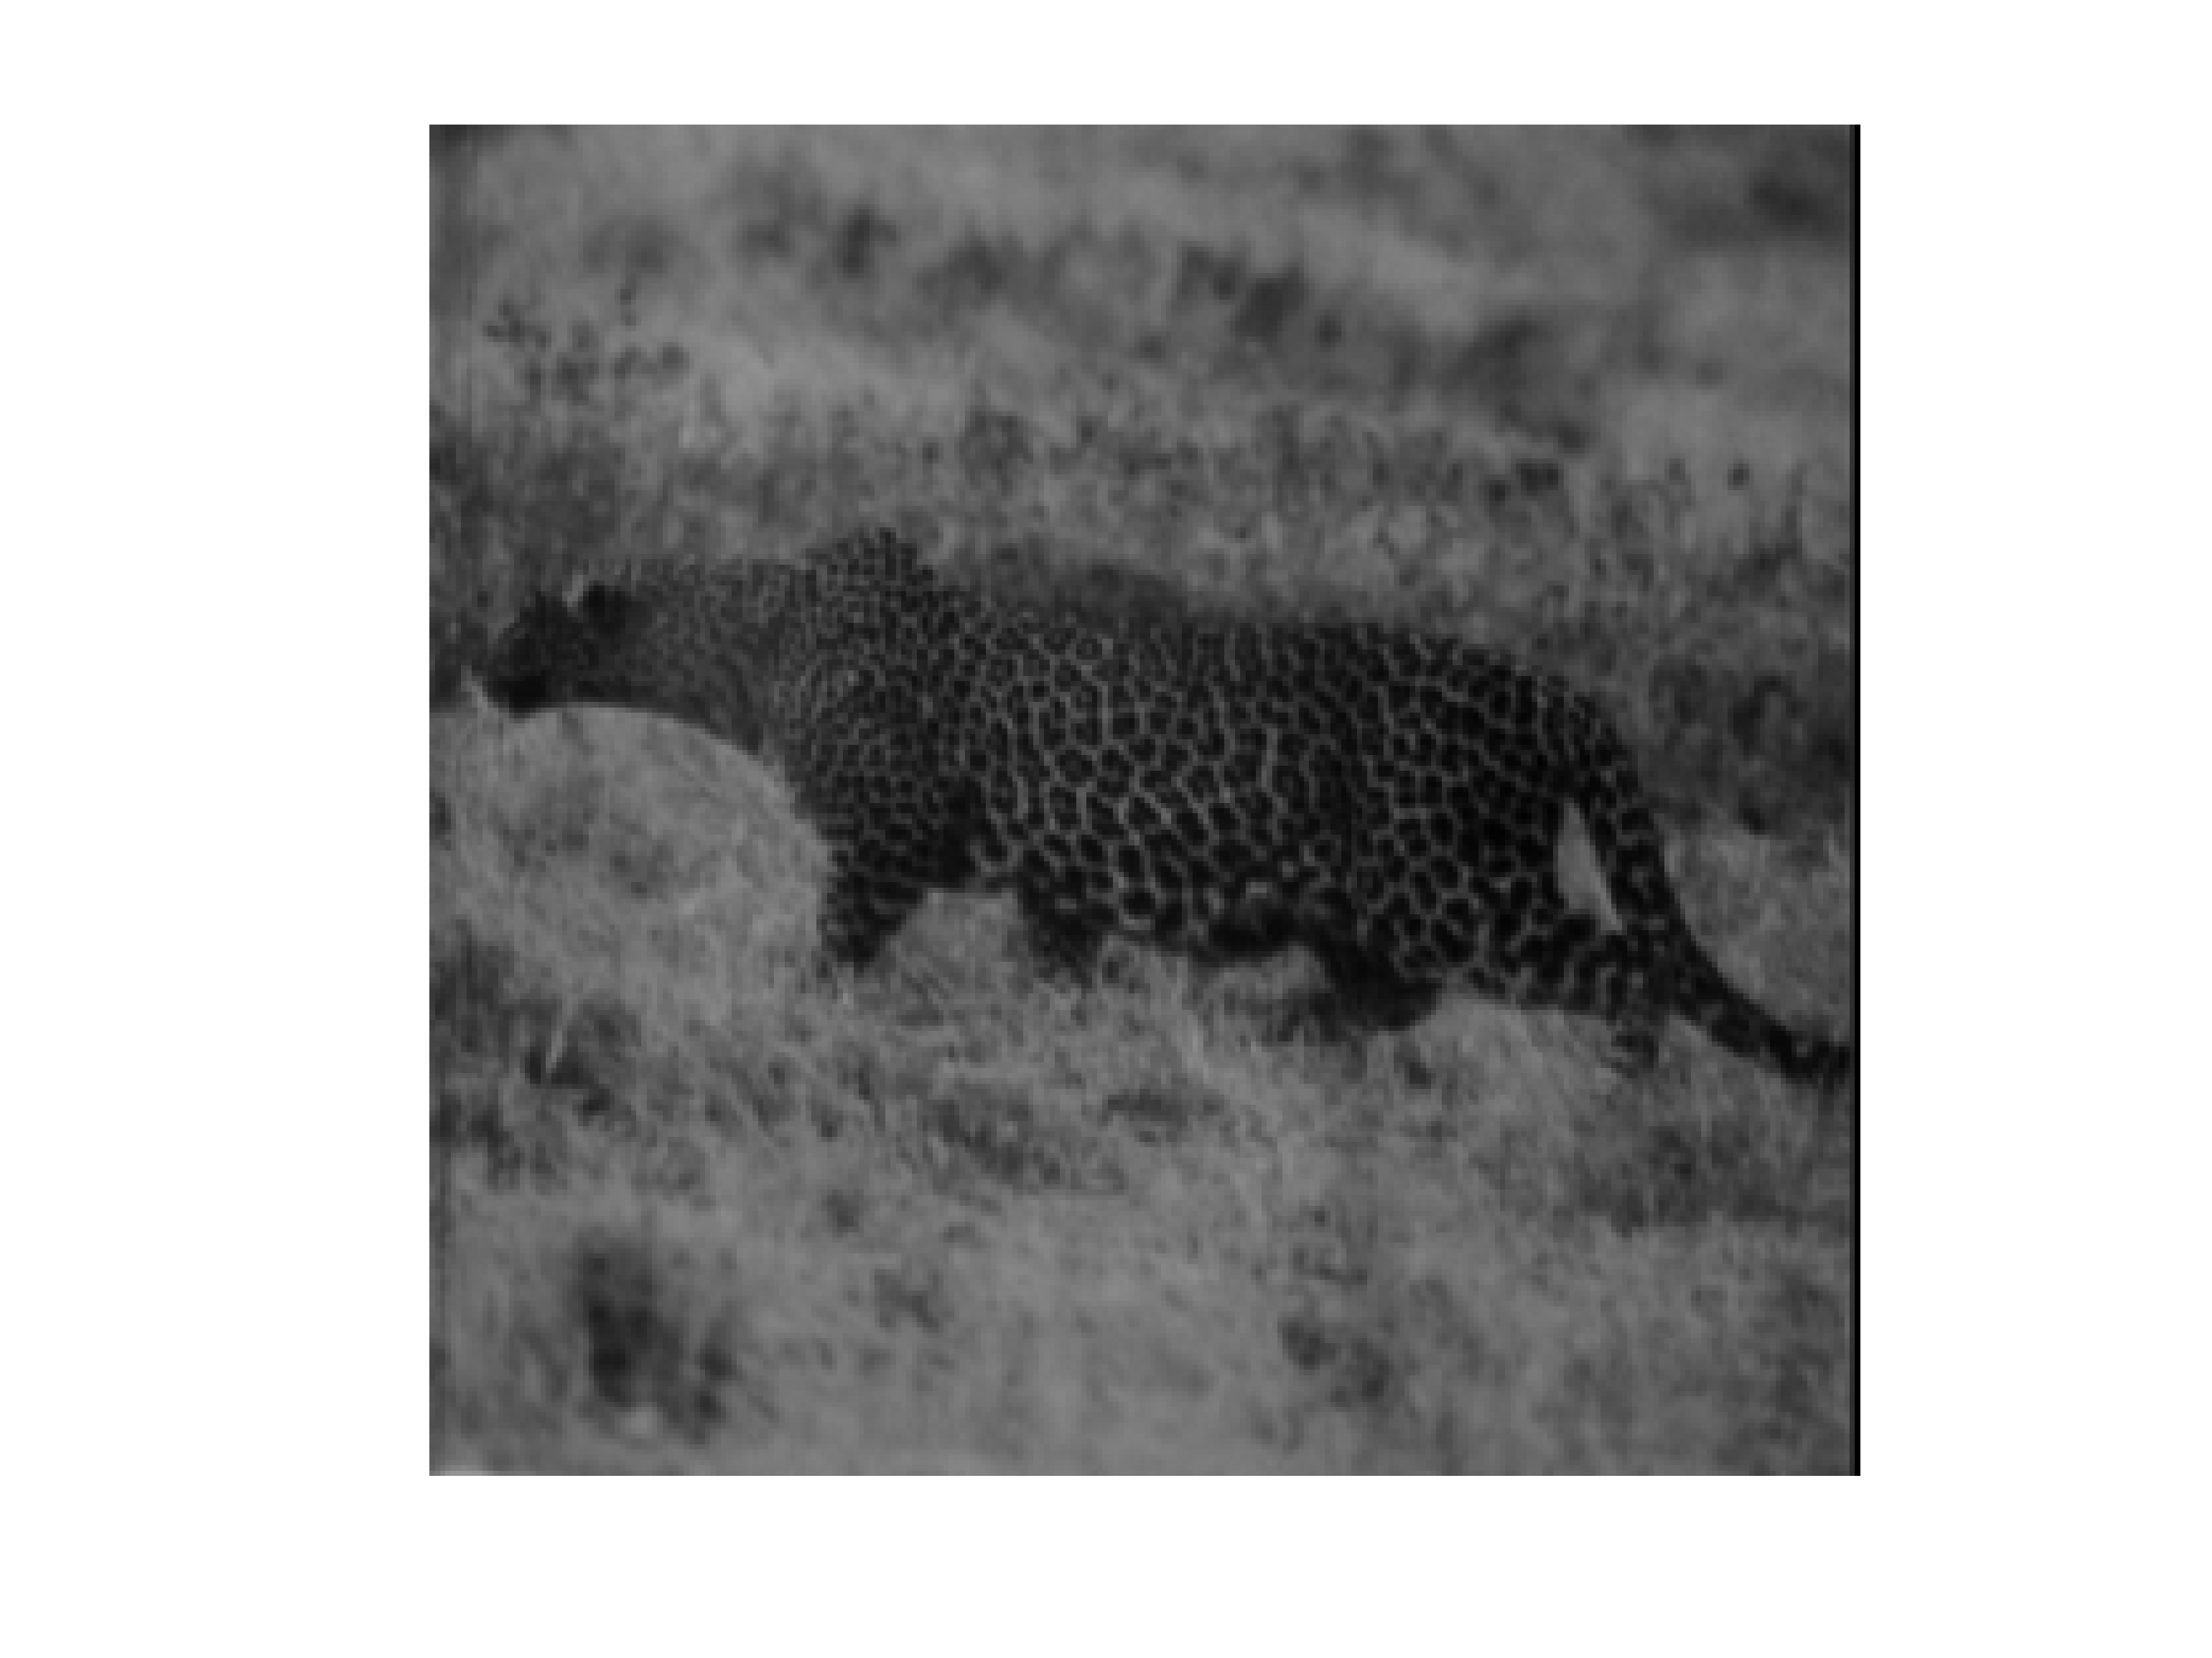

In [2]:
I = imread("cheetah.bmp");
figure
imshow(I)


Ground truth


In [3]:
I_ground = imread("cheetah_mask.bmp");
I_ground_double = im2double(I_ground);


Padding the edges of the image for sliding window


In [4]:
image = im2double(I); %255x270
win_dim = 8; % 8x8
pad_x_dir = win_dim/2;
pad_y_dir = win_dim/2;
I_pad = padarray(image,[pad_x_dir,pad_y_dir],"replicate") % 261x278 for 8x8 window with top left filter as pixel filter.

I_pad = 263x278
    0.2392    0.2392    0.2392    0.2392    0.2392    0.2353    0.2000    0.1804    0.1843    0.1882    0.1961    0.2353    0.2235    0.2392    0.2667    0.2706    0.2706    0.2784    0.3059    0.3255    0.3451    0.3686    0.3804    0.3804    0.3843    0.3686    0.3451    0.3373    0.3412    0.3529    0.3882    0.4157    0.4431    0.4471    0.4549    0.4588    0.4706    0.4784    0.4863    0.4902    0.4863    0.4863    0.4902    0.4824    0.4745    0.4863    0.4980    0.5059    0.5176    0.5294
    0.2392    0.2392    0.2392    0.2392    0.2392    0.2353    0.2000    0.1804    0.1843    0.1882    0.1961    0.2353    0.2235    0.2392    0.2667    0.2706    0.2706    0.2784    0.3059    0.3255    0.3451    0.3686    0.3804    0.3804    0.3843    0.3686    0.3451    0.3373    0.3412    0.3529    0.3882    0.4157    0.4431    0.4471    0.4549    0.4588    0.4706    0.4784    0.4863    0.4902    0.4863    0.4863    0.4902    0.4824    0.4745    0.4863    0.4980    0.5059   


DCT matrix to array \- zig zag vector


In [5]:
dct_vec_order = [1    2    6    7    15    16    28    29;
3    5    8    14    17    27    30    43;
4    9    13    18    26    31    42    44;
10    12    19    25    32    41    45    54;
11    20    24    33    40    46    53    55;
21    23    34    39    47    52    56    61;
22    35    38    48    51    57    60    62;
36    37    49    50    58    59    63    64];


Sliding window on the image and extracting the DCT matrix as array


In [6]:
k=0;
feature = ones(size(image,1)*size(image,2),win_dim*win_dim);
fl = zeros(1,win_dim*win_dim);
for i = 1:size(image,1)
    for j = 1:size(image,2)
        image_dct(i:i+win_dim-1,j:j+win_dim-1)=dct2(I_pad(i:i+win_dim-1,j:j+win_dim-1));
        k=k+1;
        fl(dct_vec_order) = image_dct(i:i+win_dim-1,j:j+win_dim-1);
        feature(k,:) = fl;
    end
end


Obtaining feature X from the flattened DCT matrix


In [7]:
X = feature;

In [8]:
% Bayesian_decision(x,FG,BG,mu_0_FG,mu_0_BG,W0,alpha,I_ground_double)
size_exp = [4,2,length(alpha)];
sol(4,2,9) = Bayesian_decision;
for i = 1:size_exp(1)
    for j = 1:size_exp(2)
        for k = 1:size_exp(3)
            fprintf('Experiment (%d, %d, %d) : ',i,j,k);
            tic
            sol(i,j,k) = Bayesian_decision(X,data{i},data{i+4},mean_prior{j},mean_prior{j+2},mean_prior{j+4},alpha(k),I_ground_double);
            toc
        end
    end
end

Experiment (1, 1, 1) : 
Elapsed time is 18.880313 seconds.
Experiment (1, 1, 2) : 
Elapsed time is 19.172650 seconds.
Experiment (1, 1, 3) : 
Elapsed time is 19.290702 seconds.
Experiment (1, 1, 4) : 
Elapsed time is 19.500861 seconds.
Experiment (1, 1, 5) : 
Elapsed time is 19.667577 seconds.
Experiment (1, 1, 6) : 
Elapsed time is 18.786694 seconds.
Experiment (1, 1, 7) : 
Elapsed time is 18.587449 seconds.
Experiment (1, 1, 8) : 
Elapsed time is 18.436092 seconds.
Experiment (1, 1, 9) : 
Elapsed time is 19.278763 seconds.
Experiment (1, 2, 1) : 
Elapsed time is 19.409015 seconds.
Experiment (1, 2, 2) : 
Elapsed time is 19.427466 seconds.
Experiment (1, 2, 3) : 
Elapsed time is 18.781017 seconds.
Experiment (1, 2, 4) : 
Elapsed time is 19.111576 seconds.
Experiment (1, 2, 5) : 
Elapsed time is 18.529292 seconds.
Experiment (1, 2, 6) : 
Elapsed time is 18.476298 seconds.
Experiment (1, 2, 7) : 
Elapsed time is 18.444698 seconds.
Experiment (1, 2, 8) : 
Elapsed time is 18.538303 second


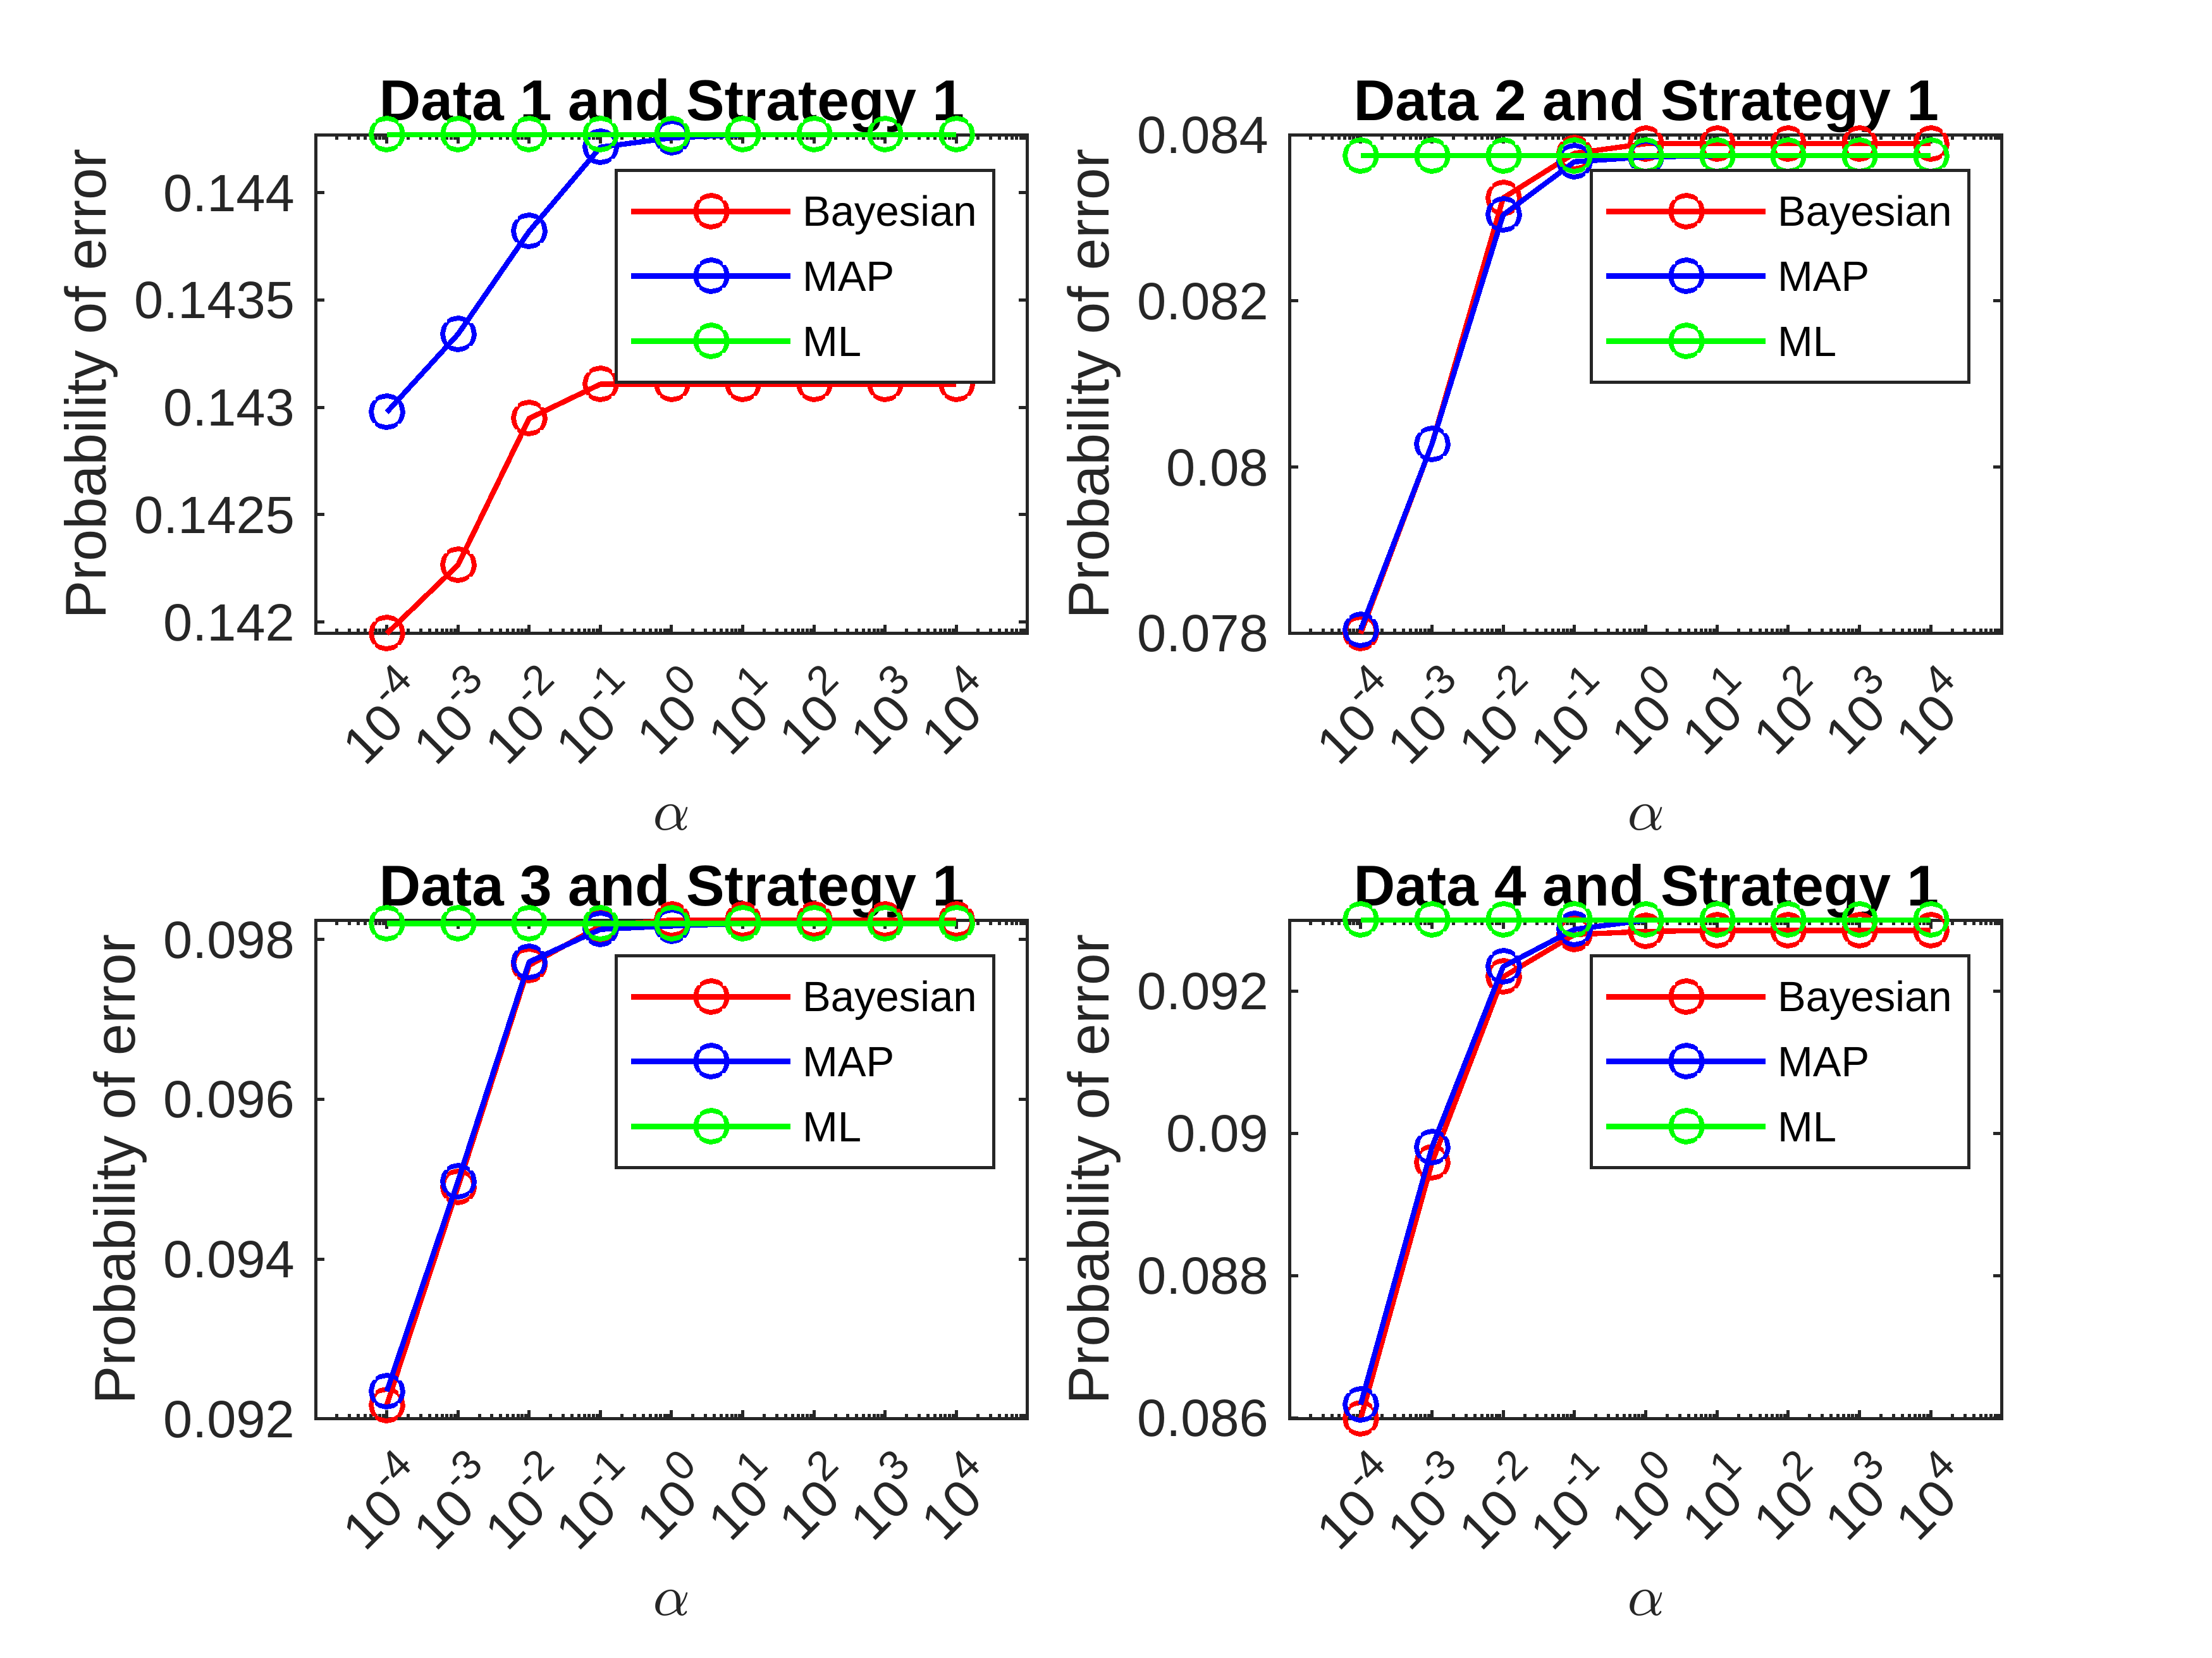


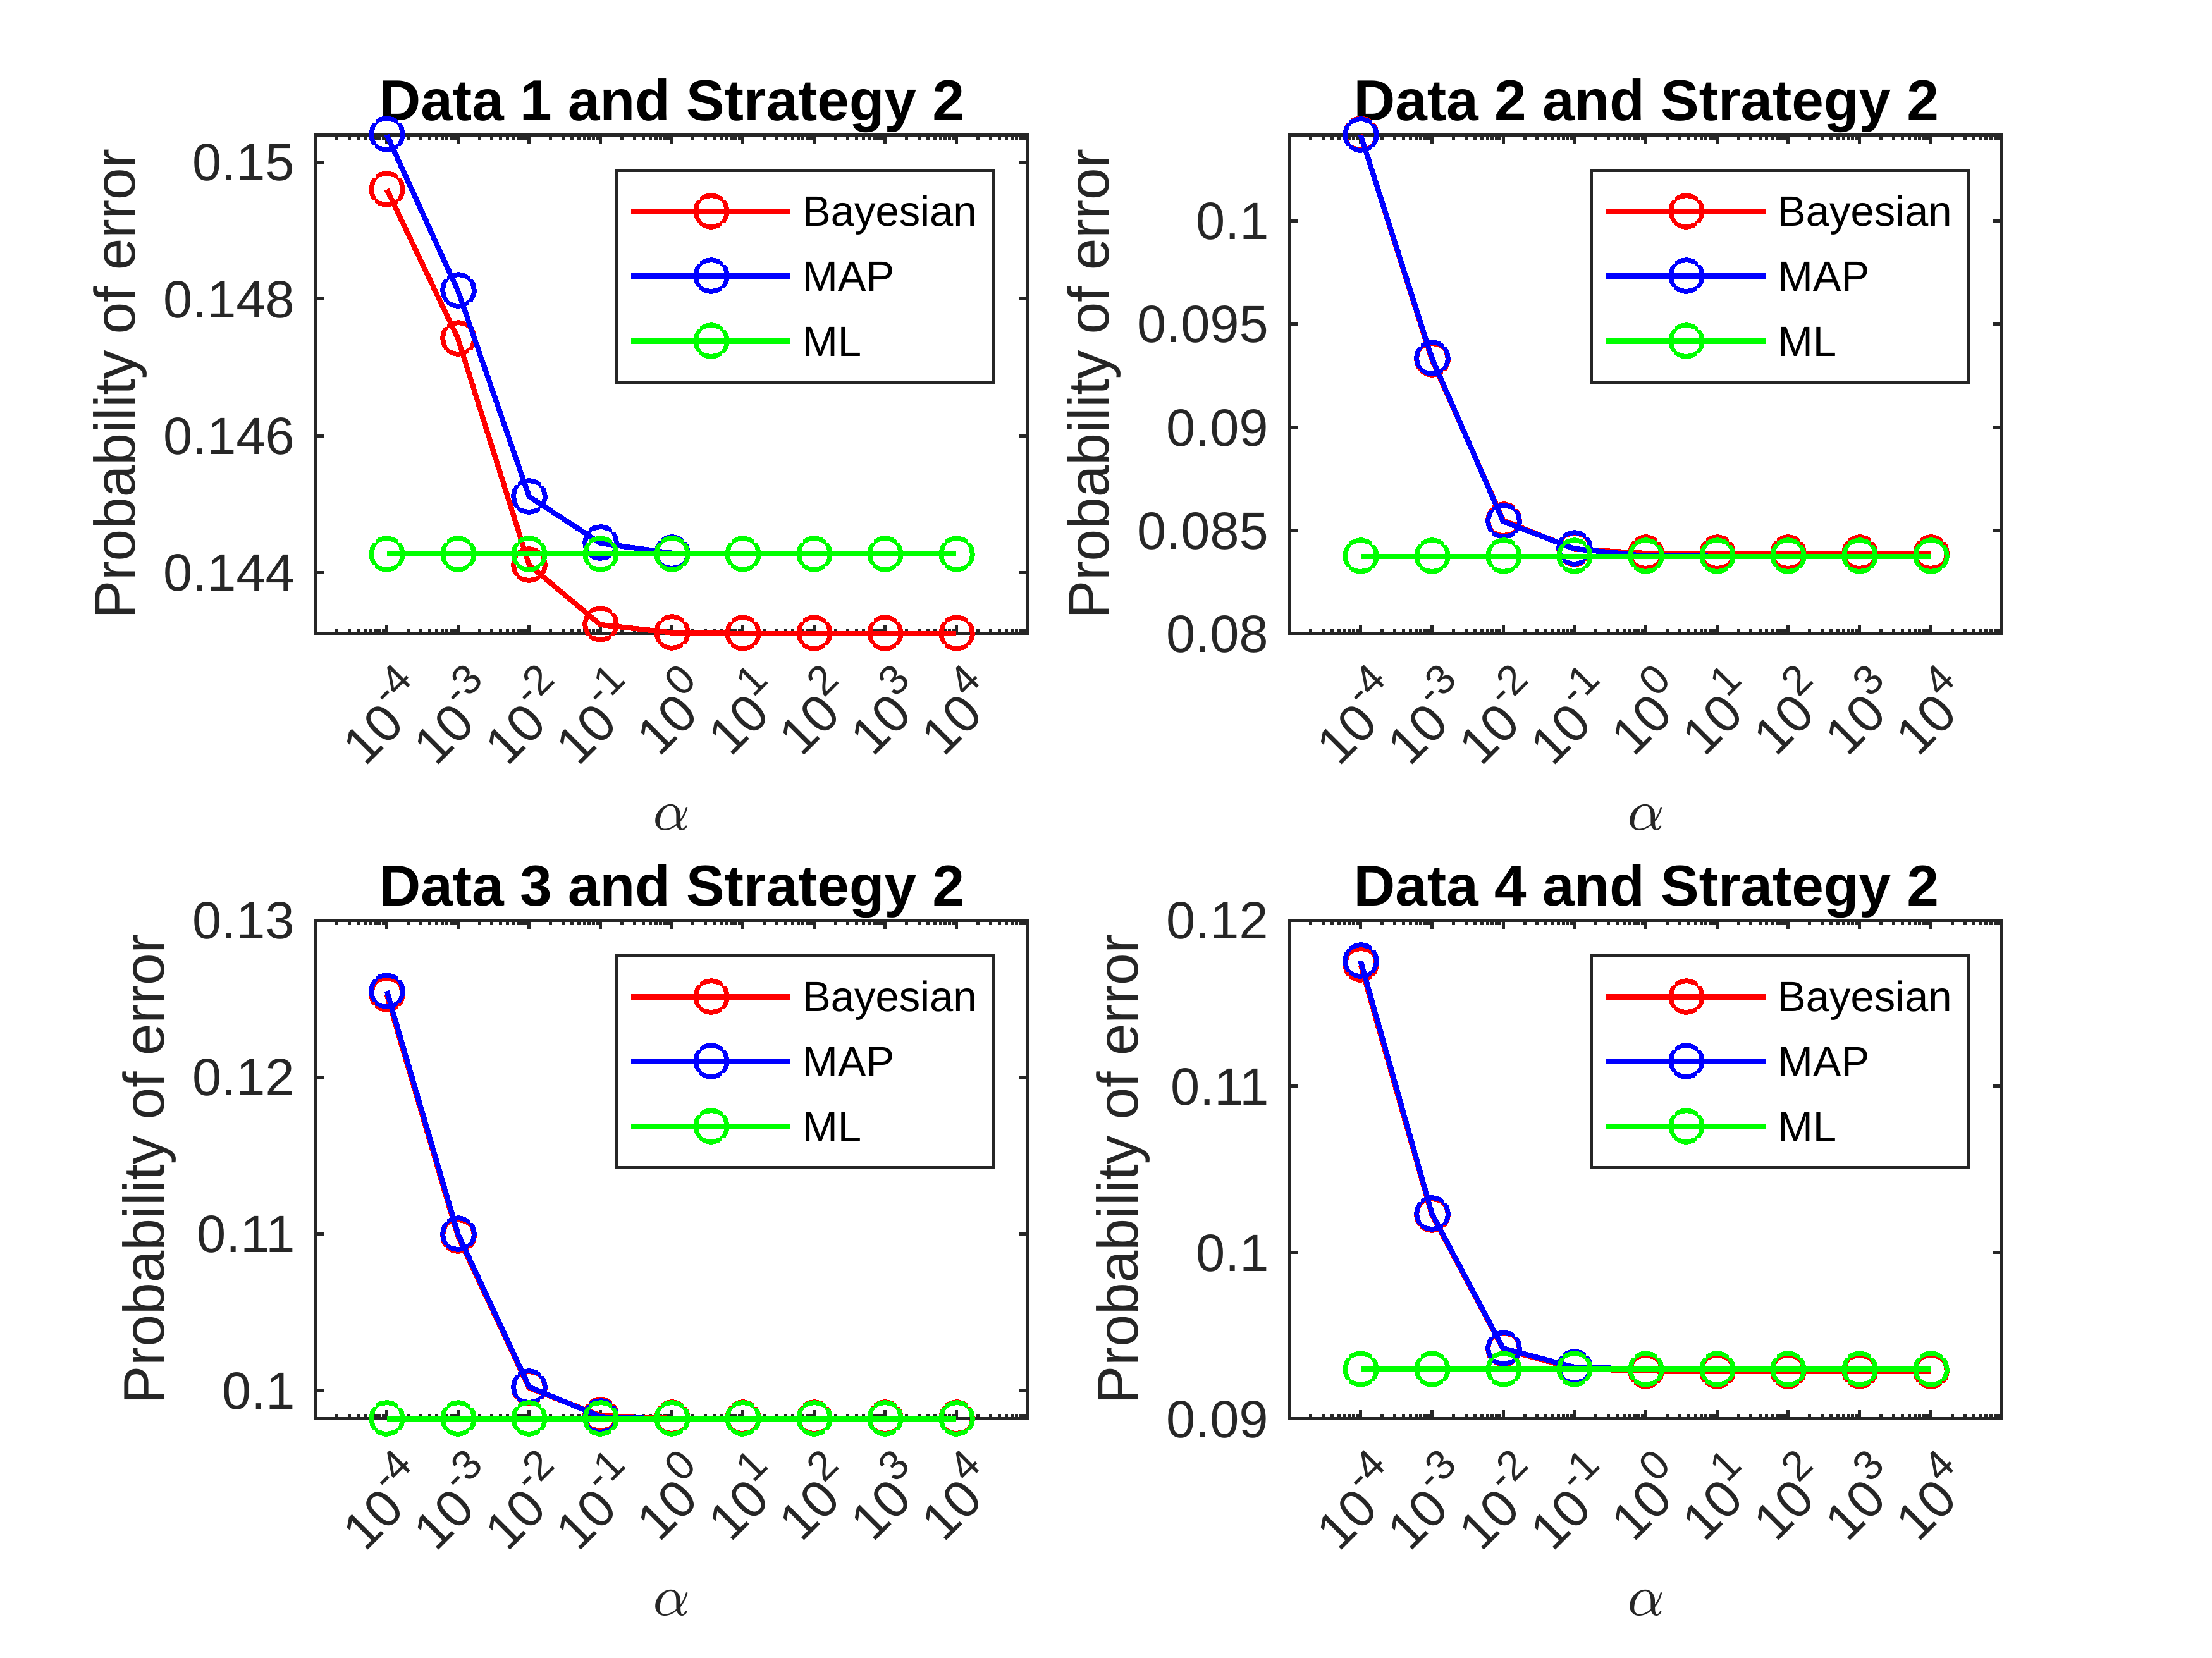

In [9]:
for i=1:size_exp(2)
    figure()
    for j=1:size_exp(1)
        subplot(2,2,j)
        semilogx(alpha,[sol(j,i,1:9).error_BPE],"-or", alpha,[sol(j,i,1:9).error_MAP],"-ob", alpha,[sol(j,i,1:9).error_ML],"-og",'LineWidth',1)
        xlabel(' !!!EQ_28!!! ', 'Interpreter', 'latex');
        ylabel('Probability of error')
        xticks(alpha)
        legend('Bayesian','MAP','ML')
        title_str = sprintf('Data %d and Strategy %d', j, i);
        title(title_str);
    end
end

In [10]:
methods('Bayesian_decision')

Methods for class Bayesian_decision:
BDR                                                   Bayesian_decision                                     Gaussian                                              Prior_prob_class                                      class_conditional_prob_MAP_estimation                 class_conditional_prob_ML_estimation                  class_conditional_prob_bayesian_parameter_estimation  covariance                                            mask_error                                            prediction                                            prob_dist_mean_given_data                             prob_dist_mean_prior                                  prob_dist_x_given_data                                prob_dist_x_given_mean


Discussion of the observations :

-  At small $\alpha$ \- { $10^{-3} ,10^{-2} ,10^{-1}$ } (small parameter covariances) for the first strategy \- { $\mu_0 =1,3$ } the error in the case of Bayesian and MAP is smaller than ML. But, if the second strategy is used \- { $\mu_0 =2$ }, Bayesian and MAP performes poorly than ML.
-  This shows that if the prior distrbution is constricted \- very less covariance, and if the expected value of the parameter $E[\mu ]$ is not correct for classification, then Bayesian and MAP will suffer. On the other hand, if we are not sure on the expected value of the parameter $E[\mu ]$ and have sufficient covariance, then Bayesian and MAP performs atleast as good as ML.
-  In Low data regime (Data 1), Bayesian performed well for sufficiently large covariance irrespective of $E[\mu ]$ (strategy 1 or 2) used. In the low data regime, the information about prior distribution of parameters helps in classfication process. By averaging through all possibilites of the parameter, we consider all possible cases. This explains why MAP is not performing better than Bayesian even though it considers prior information about the parameter.
-   As the data size increases, the error reduced in all three cases and the best error we get is the ML estimation error. This shows that Bayesian and MAP is useful in very sparse data availability conditions. If sufficient data is available then, the simplest estimator : ML performs satisfactorily.
